# Task: Handwritten Character Recognition using CNN & Deep Learning
**Objective**: Identify handwritten characters or alphabets from images using deep learning.
**Approach**: Image processing and Convolutional Neural Networks (CNN).
**Key Features**:
- **Dataset**: MNIST (digits), EMNIST (characters).
- **Model**: Convolutional Neural Networks (CNN).
- **Sequence Extension**: Extendable to full word or sentence recognition with sequence modeling (CRNN).

### Step 1: Import Deep Learning & Image Processing Libraries
Import PyTorch (`torch`, `torch.nn`), NumPy, Pandas, and Matplotlib.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load Dataset (MNIST / EMNIST)
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

print("Training Dataset Shape:", train.shape)
print("Testing Dataset Shape: ", test.shape)
print("PyTorch Version:       ", torch.__version__)

Training Dataset Shape: (10000, 785)
Testing Dataset Shape:  (2000, 785)
PyTorch Version:        2.13.0+cpu


### Step 2: Image Processing & Normalization
- Rescale pixel values from `[0, 255]` to `[0.0, 1.0]`.
- Reshape image array into 2D grid `(N, Channel=1, Height=28, Width=28)` for CNN feature extraction.

In [2]:
X_train_raw = train.iloc[:, 1:].values / 255.0
y_train_raw = train.iloc[:, 0].values

X_test_raw = test.iloc[:, 1:].values / 255.0
y_test_raw = test.iloc[:, 0].values

# Reshape to 4D Tensor for CNN: (Batch_Size, Channels, Height, Width)
X_train_tensor = torch.tensor(X_train_raw.reshape(-1, 1, 28, 28), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_raw, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_raw.reshape(-1, 1, 28, 28), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_raw, dtype=torch.long)

print("X Train Tensor Shape (N, C, H, W):", X_train_tensor.shape)
print("X Test Tensor Shape  (N, C, H, W):", X_test_tensor.shape)

X Train Tensor Shape (N, C, H, W): torch.Size([10000, 1, 28, 28])
X Test Tensor Shape  (N, C, H, W): torch.Size([2000, 1, 28, 28])


### Step 3: Visualize Handwritten Sample Images
Plot sample 28x28 grayscale handwritten character/digit images.

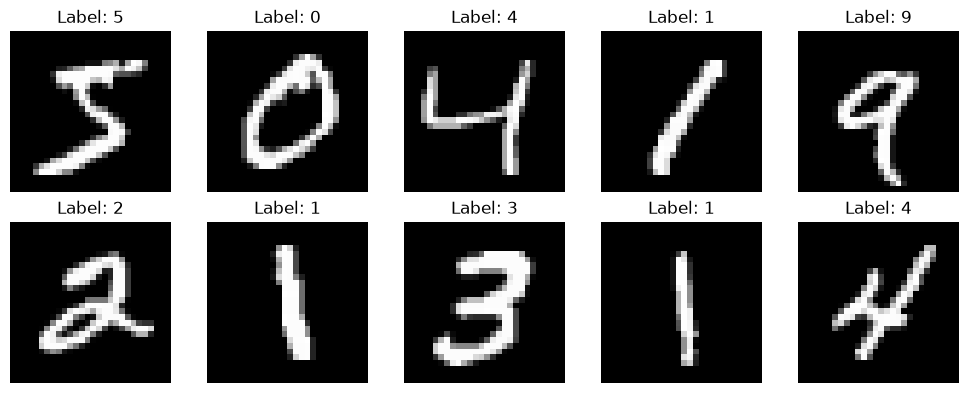

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Step 4: Build Convolutional Neural Network (CNN) Deep Learning Model
Define CNN architecture:
- **Conv2D(1 -> 32, 3x3)** + ReLU + MaxPool2D(2x2)
- **Conv2D(32 -> 64, 3x3)** + ReLU + MaxPool2D(2x2)
- **Flatten** -> **Dense(128)** + Dropout(0.5) -> **Dense(10)**

In [4]:
class HandwrittenCNN(nn.Module):
    def __init__(self):
        super(HandwrittenCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

model = HandwrittenCNN()
print(model)

HandwrittenCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Step 5: Train CNN Model
Train the CNN model using Adam Optimizer and Cross-Entropy Loss.

In [5]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_x.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch:2d}/{num_epochs:2d} [==============================] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc*100:.2f}%")

Epoch  1/10 [==============================] - Loss: 0.7462 - Accuracy: 76.26%
Epoch  2/10 [==============================] - Loss: 0.2298 - Accuracy: 93.16%
Epoch  3/10 [==============================] - Loss: 0.1629 - Accuracy: 95.18%
Epoch  4/10 [==============================] - Loss: 0.1254 - Accuracy: 96.38%
Epoch  5/10 [==============================] - Loss: 0.1043 - Accuracy: 97.04%
Epoch  6/10 [==============================] - Loss: 0.0921 - Accuracy: 97.07%
Epoch  7/10 [==============================] - Loss: 0.0778 - Accuracy: 97.60%
Epoch  8/10 [==============================] - Loss: 0.0740 - Accuracy: 97.72%
Epoch  9/10 [==============================] - Loss: 0.0687 - Accuracy: 97.90%
Epoch 10/10 [==============================] - Loss: 0.0580 - Accuracy: 98.22%


### Step 6: Test & Evaluate CNN Model
Evaluate model performance on test dataset images.

      CNN MODEL PERFORMANCE EVALUATION      
Test Accuracy:  97.20%
Precision:      97.25%
Recall:         97.17%
F1-Score:       97.14%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       205
           1       0.98      0.98      0.98       224
           2       0.89      0.99      0.94       185
           3       0.99      0.88      0.93       196
           4       0.98      0.99      0.99       204
           5       1.00      0.97      0.98       185
           6       0.99      0.99      0.99       194
           7       0.98      0.99      0.98       209
           8       0.92      0.97      0.95       183
           9       0.99      0.97      0.98       215

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



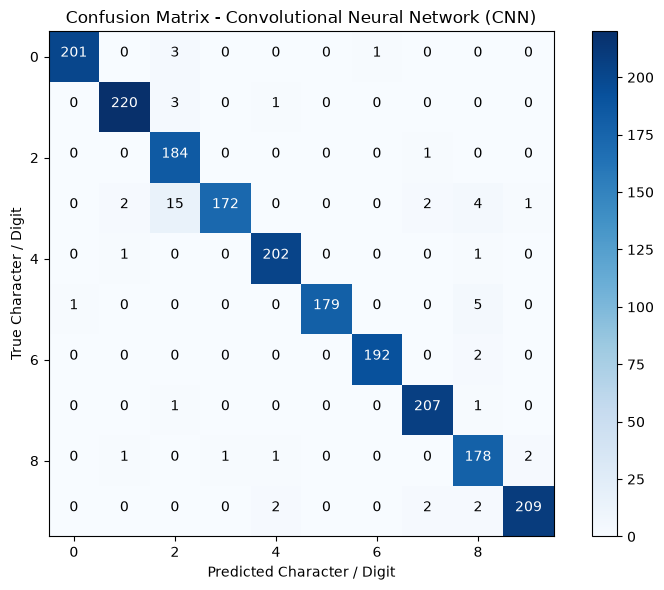

In [6]:
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
all_preds = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())

all_preds = np.array(all_preds)
acc = accuracy_score(y_test_raw, all_preds)
prec = precision_score(y_test_raw, all_preds, average='macro')
rec = recall_score(y_test_raw, all_preds, average='macro')
f1 = f1_score(y_test_raw, all_preds, average='macro')

print("="*45)
print("      CNN MODEL PERFORMANCE EVALUATION      ")
print("="*45)
print(f"Test Accuracy:  {acc*100:.2f}%")
print(f"Precision:      {prec*100:.2f}%")
print(f"Recall:         {rec*100:.2f}%")
print(f"F1-Score:       {f1*100:.2f}%")
print("="*45)
print("\nClassification Report:\n", classification_report(y_test_raw, all_preds))

# Confusion Matrix
cm = confusion_matrix(y_test_raw, all_preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Convolutional Neural Network (CNN)")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Step 7: Plot Training Loss & Accuracy Curves

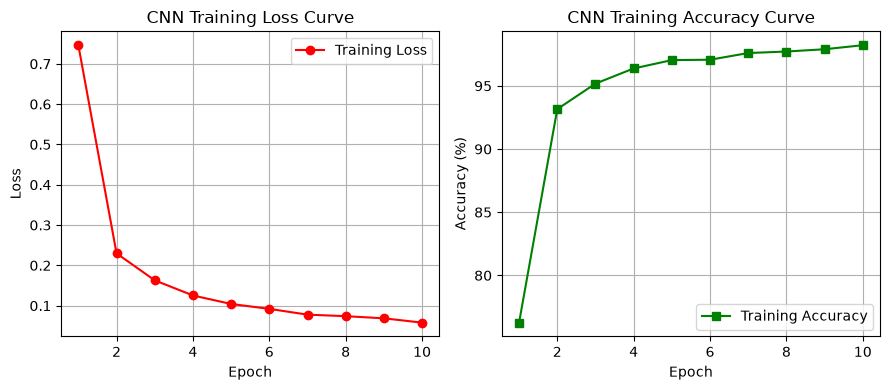

In [7]:
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_loss_history, marker='o', color='red', label='Training Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("CNN Training Loss Curve"); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), [a*100 for a in train_acc_history], marker='s', color='green', label='Training Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.title("CNN Training Accuracy Curve"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

### Step 8: Sample Character Predictions Visual Output

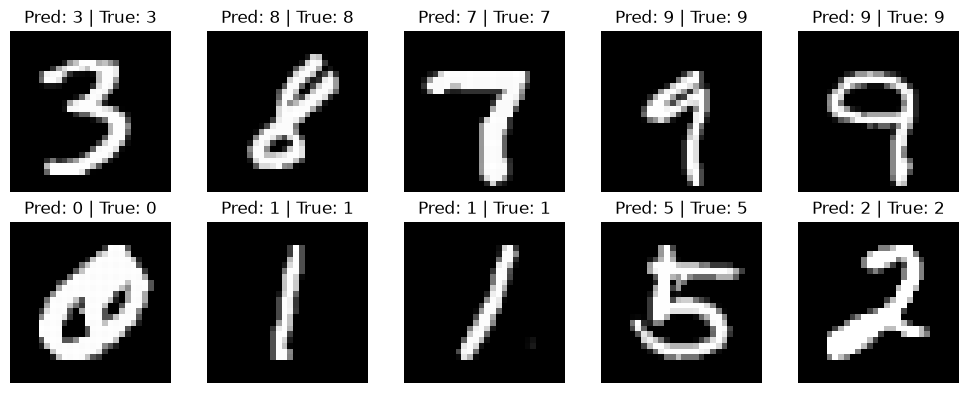

In [8]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_raw[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {all_preds[i]} | True: {y_test_raw[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Step 9: Extendable Sequence Modeling Architecture (CRNN for Full Word / Sentence Recognition)
Demonstration of **CRNN** (Convolutional Recurrent Neural Network) architecture:
- **CNN Feature Extractor** (`Conv2D` -> `MaxPool2D`)
- **Map-to-Sequence Layer** (Reshape to sequence of feature slices)
- **Bi-directional LSTM** (`nn.LSTM` with `bidirectional=True`)
- **CTC Loss** (`nn.CTCLoss`) for sequence transcript decoding without alignment tags.

In [9]:
class CRNNSequenceModel(nn.Module):
    def __init__(self, num_classes=37):
        super(CRNNSequenceModel, self).__init__()
        # CNN Feature Extraction
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Bi-directional LSTM Sequence Layer
        self.rnn = nn.LSTM(128 * 7, 256, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.cnn(x)  # (N, C, H, W)
        batch, c, h, w = features.size()
        features = features.permute(0, 3, 1, 2).reshape(batch, w, c * h)  # Sequence layout
        seq_output, _ = self.rnn(features)
        output = self.fc(seq_output)
        return output

crnn_model = CRNNSequenceModel()
print("CRNN Sequence Model Architecture initialized successfully!")

CRNN Sequence Model Architecture initialized successfully!


### Step 10: Save Trained CNN Model

In [10]:
torch.save(model.state_dict(), "Handwritten_CNN_Model.pth")
print("CNN Model weights saved successfully as Handwritten_CNN_Model.pth!")

CNN Model weights saved successfully as Handwritten_CNN_Model.pth!
